## PARIS inverse modelling results - notebook edited to produce NID/NISC style plots

This notebook contains functions to create these plots for all standard and annex species:

- Timeseries of country/region fluxes, with inventory data as bars and InTEM model output as lines.
- Tables of InTEM and inventory annual country/region fluxes, output as LaTeX-format files.
- Spatial plots of InTEM posterior flux estimates.

### Notebook setup:

1. Edit the `data_dir` to point towards where the model output is.

2. Update the `m_data` dictionary to point towards the experiment/model you want to plot.

3. Edit the species, start_date and end_date to plot either a timeseries of total fluxes or spatial map of average fluxes.

In [17]:
%load_ext autoreload
%autoreload 2
import PARIS_inversion_results as func
import copy
from numpy import isnan

### Path to results directory 
data_dir = '/data/users/intem_ghg/inversion/PARIS_results_sharing/'

### Set ppt_mode to True for bigger fonts
ppt_mode = False

###################################
s_data,m_data,annotate_coords = func.initialize_settings(ppt_mode)

f_gases = ['hfc134a','hfc143a','hfc125','hfc32','hfc23','hfc152a',
           'hfc365mfc','hfc4310mee','hfc245fa','hfc227ea',
           'pfc218','pfc318','pfc116','cf4','f11','f12',
           'h22','h141b','h142b','ct','mc','h12b1','h13b1',
           'h2402','hfo1234yf','hfo1234zee','hcfo1233zde']

m_data = {'intem':                      {'filename':'None',
                                         'label':'InTEM',
                                         'color':['royalblue','lightblue']},  #extra filename only used for total f gas plots
        'intem_NID2025_2year':          {'filename':'InTEM_NAME_EUROPE_NID2025_2year',
                                         'label':'InTEM NID 2025 2 year',
                                         'color':['royalblue','lightblue']},  
        'intem_NID2025':                {'filename':'InTEM_NAME_EUROPE_NID2025',
                                         'label':'InTEM',
                                         'color':['royalblue','lightblue']},
        'intem_NID2025_sectors':        {'filename':'InTEM_NAME_EUROPE_NID2025_sectors',
                                         'label':'InTEM',
                                         'color':['royalblue','lightblue']},
        'intem_NID2025_sectors_monthly':{'filename':'InTEM_NAME_EUROPE_NID2025_sectors',
                                         'label':'InTEM',
                                         'color':['darkorange','goldenrod']},
        'intem_NID2025_n2o':            {'filename':'InTEM_NAME_EUROPE_NID2025_3year',
                                         'label':'InTEM 1site',
                                         'color':['royalblue','lightblue']},
        'intem_NID2025_monthly':        {'filename':'InTEM_NAME_EUROPE_NID2025',
                                         'label':'InTEM',
                                         'color':['darkorange','goldenrod']}, 
        'intem_NIR2024':                {'filename':'InTEM_NAME_EUROPE_NIR2024_2year_inversion_A',
                                         'label':'InTEM NID 2024',
                                         'color':['royalblue','lightblue']},
        'intem_NIR2024_3year':          {'filename':'InTEM_NAME_EUROPE_NIR2024_3year_inversion_A',
                                         'label':'InTEM NID 2024 3yr',
                                         'color':['royalblue','lightblue']},
        'intem_NIR2024_monthly':        {'filename':'InTEM_NAME_EUROPE_NIR2024_1month_inversion_B',
                                         'label':'InTEM NID 2024 monthly',
                                         'color':['darkorange','goldenrod']},
        }

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
NOTE: If plotting units or scales look odd, edit species_info.json to fix this.


### 1. Timeseries of country/region fluxes or tables of country/region fluxes

In [ ]:
###################################
### edit variables in this block
#species_all = ['hfc134a','hfc143a','hfc125','hfc32','hfc23','hfc152a','hfc365mfc']
#species_all = ['hfc4310mee','hfc245fa','hfc227ea','pfc218','pfc318','pfc116','cf4','nf3]
#species_all = ['all_hfc','all_pfc']
#species_all = ['ch4','n2o','sf6']
species_all = ['h141b']
regions = ['UK']#,'NW_EU2']

save = False
create_figure_or_table = 'figure'
plot_all_devolved_nations = False
###################################

for species in species_all:
    
    if plot_all_devolved_nations == True:
        regions = ['ENGLAND','WALES','SCOTLAND','NORTHERNIRELAND']
        
    regions_txt = ''
    for r in regions: 
        regions_txt+=f'_{r}'
    
    if create_figure_or_table == 'figure':
        if 'hfo' in species or 'hcfo' in species:
            scale_co2eq = False
        else:
            scale_co2eq = True
    elif create_figure_or_table == 'table':
        scale_co2eq = False
        
    output_path = f'/home/users/intem_ghg/NID_2025/final_plots/{species}_country_flux{regions_txt}.png'    
    output_path_table = f'/home/users/intem_ghg/NID_2025/final_tables/{species}_country_flux_table_UK_sectors'
    
    if any(name in species for name in f_gases) or 'all' in species:   #catches all hfc, pfc, hfo, cfc, hcfc and CCl species
        period_override = None
        if 'all' in species:
            models = ['intem']#,'intem_NIR2024']
            models_priority = [0]
            start_date = ['2005-01-01']#,'2005-01-01']
            end_date = ['2025-01-01']#,'2025-01-01']
            inventory_start_date = '2005-01-01'
        else:
            models = ['intem_NID2025']#,'intem_NIR2024']
            models_priority = [0]
            start_date = ['1990-01-01']#,'1990-01-01']
            #start_date = ['2010-01-01']    #hfc23 zoom
            end_date = ['2025-01-01']#,'2025-01-01']
            inventory_start_date = '1990-01-01'
            #inventory_start_date = '2010-01-01' #hfc23 zoom
            
    elif species == 'ch4':
        models = [f'intem_NID2025_monthly',f'intem_NID2025']
        models_priority = [0,1]
        period_override = ['monthly','yearly']
        start_date = ['2012-01-01','1990-01-01']
        
        end_date = ['2025-01-01','2025-01-01','2025-01-01']
        inventory_start_date = '1990-01-01' 
        
    elif species == 'n2o':
        models = ['intem_NID2025_monthly','intem_NID2025_n2o']
        models_priority = [0,1]
        period_override = ['monthly','yearly']
        start_date = ['2012-01-01','1990-01-01']
        
        end_date = ['2025-01-01','2025-01-01','2025-01-01']
        inventory_start_date = '1990-01-01'
        
    elif species == 'sf6':
        models = ['intem_NID2025_monthly','intem_NID2025']
        period_override = ['monthly','yearly']
        models_priority = [0,1]
        start_date = ['2012-01-01','1990-01-01']
        
        end_date = ['2025-01-01','2025-01-01']
        inventory_start_date = '1990-01-01'
        
    elif species == 'nf3':
        models = ['intem_NID2025','intem_NIR2024']
        models_priority = [0]
        period_override = ['yearly','yearly']
        start_date = ['1990-01-01','1990-01-01']
        end_date = ['2025-01-01','2025-01-01']
        inventory_start_date = '1990-01-01'
        
    ###################################
    # updates priors in filesnames, based on the species and species_info.json
    m_data_updated = copy.deepcopy(m_data)
    if 'hfc' in species or 'pfc' in species:        
        if 'all' not in species:
            for k in m_data.keys():
                m_data_updated[k]['filename'] = m_data[k]['filename'].replace('*',s_data[species]['std_prior'])
                
    if type(start_date) == 'str':
        start_date = [start_date]*len(models)
        end_date = [end_date]*len(models)
        
    ###################################
    # reads in data and scales by co2eq, if needed
    ds_all_flux_scaled = {}

    if 'all' in species:
        
        ds_all_flux_scaled = func.read_flux_total_fgases(data_dir,species,models,s_data,m_data_updated,
                                                        regions,start_date,end_date,
                                                        period_override=period_override)
            
    else:
        ds_all_flux = func.read_flux(data_dir,species,models,s_data,m_data_updated,period_override=period_override)

        for i,m in enumerate(models):
            ds_all_flux_scaled[m] = func.slice_flux({m:ds_all_flux[m]},start_date[i],end_date[i],s_data,scale_units=True,
                                                    scale_co2eq=scale_co2eq,species=species)[m]

    ###################################
    ### edit variables in this block
    plot_inventory = True
    inventory_years = None              #['2025'] #If None, plots most recent. Or can choose list of years: ['2022','2023']. Uncertainties only plotted for most recent year.
    fix_y_axes = False                 #if True: all y axis limits are the same, if False: each y axis is relative to the data
                                        #if a list of floats (e.g. [0,0.1]) applies these limit to all axes
    add_prior_unc = False               #if True: plots prior uncertainty as shaded area
    set_global_leg = False              #If True, plots one single legend instead of one legend per subplot.
    country_codes_as_titles = False     #If True, lists 3-letter country codes under region names in subplot titles
    skip_country_title = True
    plot_separate = True                #If True, includes all model results as separate lines
    plot_combined = False               #If True, includes combined results, averaged from all models
    resample_uncert_correlation = False #If True, uses mean uncertainty during resampling, if False, recalculates uncertainty assuming no correlation
    plot_resample_and_original = False  #If True, plots both the resampled and original data
    combine_to_one_timeseries = False   #If True, combines all model output into one timeseries, using model_priority
    plot_grid = False                   #If True, includes background light grey gridlines
    nid_style_plot = True
    seasonal_mean = False               # If True, plots the average flux from each month, instead of the usual flux timeseries
    plot_prior = [False] * len(models)  #if True, plots prior mean as a dashed line for all models, if list of [True,False] only plots prior for selected models
    
    ###################################
    ### edit variables in this block
    ### set rolling_mean to [3] for 1-year to 3-year averaging
    ### or set resample to ['year'] for monthly to yearly averaging
    if species in ['ch4','sf6']:
        resample = ['year',None]        #List of values, one for each model. If None, no resample is done. Else resample the data to the given period (options 'year' and 'season' for yearly and seasonal averages)
        rolling_mean = [None,3]         #If None, does not average results. If set to a number or a list of numbers, a rolling mean will be applied over this many periods (e.g. 3)
        
    elif species == 'n2o':
        resample = ['year',None]        #List of values, one for each model. If None, no resample is done. Else resample the data to the given period (options 'year' and 'season' for yearly and seasonal averages)
        rolling_mean = [None,3]        #If None, does not average results. If set to a number or a list of numbers, a rolling mean will be applied over this many periods (e.g. 3)
    else:
        resample = [None]*len(models)
        rolling_mean = [3]*len(models)
    ###################################

    if create_figure_or_table == 'figure':
        print('\nCreating figure...\n')
        if plot_all_devolved_nations == True:
            print('Creating one plot with all devolved nations...')
            fig = func.plot_country_flux_devolved_nations(ds_all_flux_scaled,species,regions,
                                                        s_data,m_data,
                                                        start_date,end_date,ppt_mode=ppt_mode,
                                                        scale_co2eq=scale_co2eq,
                                                        plot_inventory=True,inventory_years=inventory_years,
                                                        data_dir=data_dir,fix_y_axes=fix_y_axes,
                                                        plot_prior=plot_prior,add_prior_unc=add_prior_unc,
                                                        set_global_leg=set_global_leg,
                                                        country_codes_as_titles=country_codes_as_titles,
                                                        skip_country_title=skip_country_title,resample=resample,
                                                        resample_uncert_correlation=resample_uncert_correlation,
                                                        plot_resample_and_original=plot_resample_and_original,
                                                        period_override=period_override,plot_grid=plot_grid,
                                                        inventory_start_date=inventory_start_date,
                                                        nid_style_plot=nid_style_plot,rolling_mean=rolling_mean)
        else:
            fig = func.plot_country_flux(ds_all_flux_scaled,species,regions,
                                    s_data,m_data,start_date,end_date,ppt_mode,scale_co2eq,
                                    plot_inventory,inventory_years,data_dir,fix_y_axes,plot_prior,
                                    add_prior_unc,set_global_leg,country_codes_as_titles=country_codes_as_titles,
                                    skip_country_title=skip_country_title,
                                    plot_separate=plot_separate,plot_combined=plot_combined,
                                    resample=resample,resample_uncert_correlation=resample_uncert_correlation,
                                    plot_resample_and_original=plot_resample_and_original,
                                    period_override=period_override,
                                    plot_grid=plot_grid,inventory_start_date=inventory_start_date,
                                    nid_style_plot=nid_style_plot,rolling_mean=rolling_mean,
                                    models_priority=models_priority,combine_to_one_timeseries=combine_to_one_timeseries,
                                    seasonal_mean=seasonal_mean)
        
        if save == True:
 
           fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)
           print(f'\nPlot saved to {output_path}')
        
    elif create_figure_or_table == 'table':
        print('\nCreating Annual report table...\n')
        latexheaderitems,latexlines = func.create_annual_report_tables(ds_all_flux_scaled,models,models_priority,period_override,
                                                                       regions,data_dir,species,s_data,start_date,end_date,
                                                                       inventory_years,rolling_mean,resample,resample_uncert_correlation,
                                                                       output_path_table=output_path_table,save=save,sectors=['total'])

### 2. Posterior spatial emissions

##### Edit this cell to choose inputs:


Attempting to read data from intem_NID2025
Reading data from: /data/users/intem_ghg/inversion/PARIS_results_sharing/InTEM/ct/InTEM_NAME_EUROPE_NID2025_ct_yearly.nc
Done!

Attempting to read data from intem_NID2025
Reading data from: /data/users/intem_ghg/inversion/PARIS_results_sharing/InTEM/ct/InTEM_NAME_EUROPE_NID2025_ct_yearly_concentrations.nc
Done!

Masking data from intem_NID2025
Scaling intem_NID2025 country fluxes by 1000000.0

Masking data from intem_NID2025
Scaling intem_NID2025 units by 1e-12
Masking sea areas...

10.186990509600001


Plotting markers for: ['london', 'cardiff', 'edinburgh', 'belfast', 'dublin', 'manchester', 'birmingham', 'paris', 'berlin', 'hamburg', 'munich', 'frankfurt', 'cologne', 'rome', 'milan', 'amsterdam', 'brussels', 'bern', 'marseille']
Edit lines below line 3025 to change marker colour and size

Edit flux_lim_kgkm2yr variable in species_info.json to adjust colourbar limits.You will need to rerun the first cell of the notebook to apply the adjustm

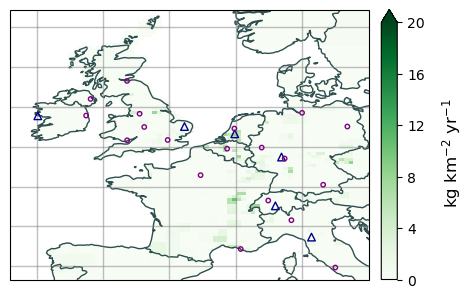

In [20]:
###################################
### edit variables in this block
#species_all = ['hfc134a','hfc143a','hfc125','hfc32','hfc23',
#               'hfc152a','hfc365mfc','hfc4310mee','hfc245fa','hfc227ea',
#             'pfc218','pfc318','pfc116','cf4','nf3','sf6','ch4','n2o']
#species_all = ['hfc134a','hfc143a','hfc125','hfc32','hfc23',
#               'hfc152a','hfc365mfc','hfc4310mee','hfc245fa','hfc227ea',
#             'pfc218','pfc318','pfc116','cf4','nf3','ct','mc']
species_all = ['ct']

#start_date = '1990-01-01' #inclusive. Option to set as list of dates, e.g. ['2018-01-01','2019-01-01'] which is required for total fgases if one model is missing obs for a year
#end_date = '1994-01-01' #not inclusive. Option to set as list of dates, e.g. ['2023-01-01','2022-01-01'] which is required for total fgases if one model is missing obs for a year

#start_date = '1994-01-01' #inclusive. Option to set as list of dates, e.g. ['2018-01-01','2019-01-01'] which is required for total fgases if one model is missing obs for a year
#end_date = '1998-01-01' #not inclusive. Option to set as list of dates, e.g. ['2023-01-01','2022-01-01'] which is required for total fgases if one model is missing obs for a year

start_date = '2021-01-01' #inclusive. Option to set as list of dates, e.g. ['2018-01-01','2019-01-01'] which is required for total fgases if one model is missing obs for a year
end_date = '2025-01-01' #not inclusive. Option to set as list of dates, e.g. ['2023-01-01','2022-01-01'] which is required for total fgases if one model is missing obs for a year

save = True
###################################

for species in species_all:

    if any(name in species for name in f_gases):   #catches all hfc, pfc, hfo, cfc, hcfc and CCl species
        models = [f'intem_NID2025']
        period_override = ['yearly']
        season_all = [None]
        outnames = ['']
        mask_sea_areas = True
    elif species == 'ch4':
        models = ['intem_NID2025']
        period_override = ['monthly']
        season_all = ['DJF','MAM','JJA','SON']
        outnames = ['_winter','_spring','_summer','_autumn']
        mask_sea_areas = False
    elif species == 'n2o':
        models = [f'intem_NID2025_monthly']
        period_override = ['monthly']
        season_all = ['DJF','MAM','JJA','SON']
        outnames = ['_winter','_spring','_summer','_autumn']
        mask_sea_areas = False
    elif species == 'sf6':
        #models = ['intem_NID2025_monthly']
        models = ['intem_sf6_paper']
        period_override = ['3monthly']
        season_all = [None]
        outnames = ['']
        mask_sea_areas = True
    elif species == 'nf3':
        models = ['intem_NID2025']
        period_override = ['yearly']
        season_all = [None]
        outnames = ['']
        mask_sea_areas = True
        
    ###################################
        
    # used to update priors in filesnames, based on the species and species_info.json
    m_data_updated = copy.deepcopy(m_data)
    if 'hfc' in species or 'pfc' in species:
        for k in m_data.keys():
            m_data_updated[k]['filename'] = m_data[k]['filename'].replace('*',s_data[species]['std_prior'])
            
    ds_all_flux = func.read_flux(data_dir,species,models,s_data,m_data,period_override=period_override)
    
    # tseries file read in used to find sites with data in this period, for accurate site location plotting
    ds_all_mf = func.read_mf(data_dir,species,models,s_data,m_data,period_override=period_override)

    ds_all_flux_scaled = {}
    ds_all_mf_sliced = {}
    
    for m in models:
        ds_all_flux_scaled[m] = func.slice_flux({m:ds_all_flux[m]},start_date,end_date,s_data,scale_units=True,
                                                scale_co2eq=False,species=species)[m]
        ds_all_mf_sliced[m] = func.slice_mf({m:ds_all_mf[m]},s_data,start_date,end_date,site=None,baseline_site=None,
                                            data_dir=data_dir,scale_units=True,species=species)[m]
    
    ###################################
    
    sites_available = {}
    for m in models:
        sites_available[m] = []
        for s in range(ds_all_mf_sliced[m].nsite.values.shape[0]):
            if all(isnan(ds_all_mf_sliced[m]['Yobs'].values[:,s])) is False: 
                sites_available[m].append(ds_all_mf_sliced[m]['sitenames'].values[s])
    
    ###################################
    ### edit variables in this block
    plot_area = 'AREUROPE'                  #options for: UK, FRANCE, GERMANY, ITALY, SWITZERLAND, NWEU, CWEU, EUROPE, AR_EUROPE
    cmap = 'Greens'                      #flux colour (e.g. 'viridis', 'coolwarm') #use 'green', 'blue' or 'greyscale' to replicate NISC plots
    cmap_diff = 'coolwarm'
    c_border = 'darkslategrey'          #country boundary colour (e.g. 'floralwhite', 'dimgrey')
    var = 'flux_total_posterior'        #variable to be plotted. Options for: 'flux_total_posterior', 'flux_total_prior'
    plot_site_locations = True          #If True, adds markers to plots at locations of obs sites
    if plot_area == 'AREUROPE':
        plot_point_markers = ['london','cardiff','edinburgh','belfast','dublin','manchester','birmingham',
                            'paris','berlin','hamburg','munich','frankfurt','cologne','rome','milan','amsterdam',
                            'brussels','bern','marseille']
    else:
        plot_point_markers = ['london','cardiff','edinburgh','belfast','dublin','manchester','birmingham']
    plot_inversion_grid_flux = True     #If True, plots fluxes at resolution of inversion, if False, plots at the resolution of the prior
    scale_to_kgkm2yr = True             #If True, outputs fluxes in kg/km2/year. If False, uses mol/m2/s.
    nid_style_plot = True               #If True, adds NID-style formatting, e.g. adjusts scales, uses different symbols for point_source_markers etc.
    include_threshold = False           #If True, sets a minimum plotting value, using values set in the first cell of this notebook.
    plot_one_average = True             #If True, plots one map of the average between start_date and end_date, if False plots a grid of maps, one per timestamp in the emissions file
    ###################################
    
    if plot_one_average == True:

        for i,season in enumerate(season_all):
            
            output_path = f'/home/users/intem_ghg/NID_2025/final_plots/{species}_posterior_map{outnames[i]}_{plot_area}_{start_date[:4]}-{int(end_date[:4])-1}.png'
            #output_path = f'/home/users/intem_ghg/NID_2025/final_plots/{species}_posterior_map{outnames[i]}_{plot_area}.png'
            
            fig = func.plot_spatial_flux_one_variable(ds_all=ds_all_flux_scaled,species=species,plot_area=plot_area,
                                                    s_data=s_data,m_data=m_data,var=var,
                                                    cmap=cmap,cmap_diff=cmap_diff,c_border=c_border,
                                                    period_override=period_override,plot_site_locations=plot_site_locations,
                                                    plot_point_markers=plot_point_markers,season=season,
                                                    plot_inversion_grid_flux=plot_inversion_grid_flux,
                                                    scale_to_kgkm2yr=scale_to_kgkm2yr,
                                                    nid_style_plot=nid_style_plot,mask_sea_areas=mask_sea_areas,
                                                    include_threshold=include_threshold,sites_available=sites_available)
            
    else:
        
        fig = func.plot_spatial_flux_by_timestamp(ds_all=ds_all_flux_scaled,species=species,plot_area=plot_area,
                                                    s_data=s_data,m_data=m_data,var=var,
                                                    cmap=cmap,cmap_diff=cmap_diff,c_border=c_border,
                                                    period_override=period_override,plot_site_locations=plot_site_locations,
                                                    plot_point_markers=plot_point_markers,
                                                    plot_inversion_grid_flux=plot_inversion_grid_flux,
                                                    scale_to_kgkm2yr=scale_to_kgkm2yr,
                                                    nid_style_plot=nid_style_plot,mask_sea_areas=mask_sea_areas,
                                                    include_threshold=include_threshold,sites_available=sites_available)

    if save == True:
        fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)
        print(f'Saved to: {output_path}')

##### Prior and posterior fluxes for all models:

In [ ]:
###################################
### edit variables in this block
plot_area = 'UK' #options for: UK, FRANCE, GERMANY, ITALY, SWITZERLAND, NWEU, CWEU, EUROPE
cmap = 'green'   #Greens
cmap_diff = 'coolwarm'
c_border = 'dimgrey'    #country boundary colour
plot_site_locations = True #If True, adds markers to plots at locations of obs sites 
plot_point_markers = ['paris','london'] #plot a marker at these locations, options for 'paris', 'london', 'nw_england' (PFC-218 source) or any value [lon,lat]
season = None #If specified plot the seasonal mean (only valable for monthly data). Options for 'DJF', 'MAM', 'JJA' and 'SON'
plot_inversion_grid_flux = True #If True, plots fluxes at resolution of inversion, if False, plots at the resolution of the prior
NISC_plot = True
###################################

fig = func.plot_spatial_flux(ds_all_flux_scaled,species,plot_area,s_data,m_data,
                             cmap=cmap,cmap_diff=cmap_diff,c_border=c_border,
                             period_override=period_override,plot_site_locations=plot_site_locations,
                             plot_point_markers=plot_point_markers,
                             season=season,plot_inversion_grid_flux=plot_inversion_grid_flux)

##### Directly compare posterior fluxes from two models:

In [ ]:
fig = func.plot_spatial_flux_comparison(ds_all_flux_scaled,species,plot_area,s_data,m_data,ppt_mode,
                                        cmap=cmap,cmap_diff=cmap_diff,c_border=c_border,
                                        period_override=period_override,
                                        plot_site_locations=plot_site_locations,
                                        plot_point_markers=plot_point_markers,
                                        plot_inversion_grid_flux=plot_inversion_grid_flux)

### 3. Timeseries of sector-level country/region fluxes

In [ ]:
###################################
### edit variables in this block
species_all = ['ch4']
regions = ['FRANCE']#,'NW_EU2'] 
sectors = ['agric','energy','waste','industry']
sector_colors = ['darkgreen','dodgerblue','purple','grey']
sector_labels = ['Agriculture','Energy','Waste','Industry']

save = False
create_figure_or_table = 'figure'   #add table option later
plot_all_devolved_nations = False
###################################

for species in species_all:
    
    if plot_all_devolved_nations == True:
        regions = ['ENGLAND','WALES','SCOTLAND','NORTHERNIRELAND']
        
    regions_txt = ''
    for r in regions: 
        regions_txt+=f'_{r}'
    
    if create_figure_or_table == 'figure':
        scale_co2eq = False
    elif create_figure_or_table == 'table':
        scale_co2eq = False
        
    output_path = f'/home/users/intem_ghg/NID_2025/final_plots/{species}_sector_country_flux{regions_txt}_yearly_monthly_combined_Gg_units.png'
    #output_path = f'/home/users/intem_ghg/NID_2025/final_plots/timeseries_combined_PFC.png'
    
    output_path_table = f'/home/users/intem_ghg/NID_2025/final_tables/{species}_country_flux_table{regions_txt}_sectors'
            
    if species == 'ch4':
        models = [f'intem_NID2025_sectors_monthly',f'intem_NID2025_sectors']
        models_priority = [0,1]
        period_override = ['monthly','yearly']
        start_date = ['2012-01-01','1990-01-01']
        
        end_date = ['2025-01-01','2025-01-01']#,'2025-01-01']
        inventory_start_date = '1990-01-01' 
        
    elif species == 'n2o':
        models = ['intem_NID2025_monthly','intem_NID2025_n2o']
        models_priority = [0]#,1]
        period_override = ['monthly']#,'yearly']
        start_date = ['2012-01-01']#,'1990-01-01'] 
        
        end_date = ['2025-01-01','2025-01-01','2025-01-01']
        #inventory_start_date = '1990-01-01'
        inventory_start_date = '2012-01-01' #shortrun
    
    if type(start_date) == 'str':
        start_date = [start_date]*len(models)
        end_date = [end_date]*len(models)
        
    ###################################
    # reads in data and scales by co2eq, if needed
    ds_all_flux_scaled = {}

    ds_all_flux = func.read_flux(data_dir,species,models,s_data,m_data,period_override=period_override)

    for i,m in enumerate(models):
        ds_all_flux_scaled[m] = func.slice_flux({m:ds_all_flux[m]},start_date[i],end_date[i],s_data,scale_units=True,
                                                    scale_co2eq=scale_co2eq,species=species)[m]
    
    ###################################
    ### edit variables in this block
    plot_inventory = True
    inventory_years = None              #['2025'] #If None, plots most recent. Or can choose list of years: ['2022','2023']. Uncertainties only plotted for most recent year.
    fix_y_axes = False #[0,160]                 #if True: all y axis limits are the same, if False: each y axis is relative to the data
                                        #if a list of floats (e.g. [0,0.1]) applies these limit to all axes
    add_prior_unc = False               #if True: plots prior uncertainty as shaded area
    set_global_leg = False              #If True, plots one single legend instead of one legend per subplot.
    country_codes_as_titles = False     #If True, lists 3-letter country codes under region names in subplot titles
    skip_country_title = True
    plot_separate = True                #If True, includes all model results as separate lines
    plot_combined = False               #If True, includes combined results, averaged from all models
    resample_uncert_correlation = False #If True, uses mean uncertainty during resampling, if False, recalculates uncertainty assuming no correlation
    plot_resample_and_original = False  #If True, plots both the resampled and original data
    combine_to_one_timeseries = True   #If True, combines all model output into one timeseries, using model_priority
    period_override = None              #use to override standard inversion periods, must be a list the same length as models, e.g. ['monthly','yearly']
    plot_grid = False                   #If True, includes background light grey gridlines
    nid_style_plot = True
    seasonal_mean = False               # If True, plots the average flux from each month, instead of the usual flux timeseries
    resample = ['year',None]
    rolling_mean = [None,3]
    include_uncert = False               #If True, outputs uncertainty values to table
    use_NAEI_data = True                #If True, uses sector-level NAEI data for inventory columns in tables. If False, uses UNFCCC total values for all inventory columns
    ###################################

    if create_figure_or_table == 'figure':
        print('\nCreating figure...\n')
        fig = func.plot_country_sector_flux(ds_all_flux_scaled,species,regions,
                      s_data,m_data,sectors,sector_colors,sector_labels,
                      start_date,end_date,
                      scale_co2eq=scale_co2eq,resample=resample,
                      resample_uncert_correlation=resample_uncert_correlation,
                      plot_resample_and_original=plot_resample_and_original,
                      period_override=period_override,fix_y_axes=fix_y_axes,
                      rolling_mean=rolling_mean,models_priority=models_priority,
                      combine_to_one_timeseries=combine_to_one_timeseries,seasonal_mean=seasonal_mean)
        
        if save == True:
 
           fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)
           print(f'\nPlot saved to {output_path}')
        
    elif create_figure_or_table == 'table':
        print('\nCreating Annual report table...\n')
        latexheaderitems,latexlines = func.create_annual_report_tables(ds_all_flux_scaled,models,models_priority,period_override,
                                regions,
                                data_dir,species,s_data,start_date,end_date,inventory_years,
                                rolling_mean,resample,resample_uncert_correlation,
                                output_path_table,save,
                                sectors,include_uncert,use_NAEI_data)

#### Plot inventory (NAEI) sector bar chart

In [ ]:
inv_sectors = ['Agric','Energy','Waste','Indus','Land']
inv_labels = ['Agriculture','Energy','Waste','Industry','LULUCF']
inv_colors = ['darkgreen','dodgerblue','purple','grey','tan']
start_date = '1990-01-01'
end_date = '2025-01-01'

fix_y_axes = [0,160]
scale_co2eq = True
save = True
output_path = f'/home/users/intem_ghg/NID_2025/final_plots/{species}_sector_country_flux_NAEI{regions_txt}.png'

fig = func.plot_inventory_sector_flux(start_date,end_date,inv_sectors,inv_labels,inv_colors,species,
                               s_data=s_data,fix_y_axes=fix_y_axes,scale_co2eq=scale_co2eq)

if save == True:
    fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)
    print(f'\nPlot saved to {output_path}')

### 4. Modelled and observed mole fractions and/or baselines - these functions have not been edited from the original PARIS notebook, but should still work

##### Edit and run this cell to choose inputs and read in the data:

In [ ]:
###################################
### edit variables in this block
species = 'ch4' 
site = 'MHD'
models = ['intem_NID2025_monthly']#,'intem_NID2025_2year']
period_override = None  #use to override standard inversion periods, must be a list the same length as models, e.g. ['monthly','yearly']
start_date = '2007-01-01' #inclusive
end_date = '2024-01-01'   #not inclusive

baseline_site = None #'MHD', 'JFJ' or 'CMN'. If None, does not mask by baseline time
###################################

###################################
### options for variables to include in the functions below 
# Yobs                - total observed mole fraction
# uYobs_repeatability - observed repeatability mole fraction uncertainty
# uYobs_variability   - observed variability mole fraction uncertainty
# uYmod               - model mole fraction uncertainty
# uYtotal             - total mole fraction uncertainty
# Yapriori            - prior total mole fraction
# Yapost              - posterior total mole fraction
# YaprioriBC          - prior baseline
# YapostBC            - posterior baseline
# Ybias               - posterior bias added to site
# YaprioriOuter       - prior mole fractions only from outer regions
# YapostOuter         - posterior mole fractions only from outer regions
###################################


ds_all_mf = func.read_mf(data_dir,species,models,s_data,m_data,period_override=period_override)

ds_all_mf_sliced = func.slice_mf(ds_all_mf.copy(),s_data,start_date,end_date,site,baseline_site=baseline_site,
                              data_dir=data_dir,
                              scale_units=True,species=species)

#### Plot timestamps with data at each site:

In [ ]:
fig = func.plot_sites_timeseries(ds_all_mf,'Yapost',start_date,end_date,m_data)

Save plot:

In [ ]:
# output_path = '/project/paris/users/AlexDanjou/images/sites.png'

# fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

#### Timeseries plot, separated by model:

In [ ]:
fig = func.plot_obs_modelled_separate(ds_all_mf_sliced,species,site,
                                    s_data,m_data,annotate_coords,ppt_mode,
                                    include=['uYobs_variability'],
                                    diff_include=['uYobs_variability'],
                                    y_lim=None)

###################################
### Instructions for timeseries plotting: 
# - Add variables that you want to plot in "include"
# - To plot the histogram of the variables in "include", leave "diff_include" empty
# - To plot the histogram of Obs-variable, add the desired variable to be subtracted in "diff_include" (default value of "diff_include" = Yapost)
# - To erase uncertainty bars around the mean values of Yobs and Yapost set "add_unc" to False (default value of "add_unc" = True)
# - To choose y axis limits set y_lim=[min_value,max_value]
###################################

Save plot:

In [ ]:
#output_path = f'/home/h02/aramsden/PARIS_results/plots/2024_11_NISC/nf3_testing/nf3_{site}_Yapost_2018_2023.png'

fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

#### Timeseries plot, all models together:

In [ ]:
fig = func.plot_obs_modelled_together(ds_all_mf_sliced,species,site,
                                    s_data,m_data,annotate_coords,ppt_mode,
                                    include=['Yapost'],
                                    diff_include=['Yapost'],
                                    y_lim=None)

Save plot:

In [ ]:
# output_path = '/project/paris/users/AlexDanjou/images/Yapost_allmodels.png'

# fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

#### Absolute differences between two models:

In [ ]:
fig = func.plot_obs_diff(ds_all_mf_sliced,species,site,
                        s_data,m_data,annotate_coords,ppt_mode,
                        include=['Yapost'],
                        diff_include=['Yapost'],
                        y_lim=None)

Save plot:

In [ ]:
# output_path = '/project/paris/users/AlexDanjou/images/Yapost_diff.png'

# fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

#### Calculate and plot stats for the fit to obs:

In [ ]:
ds_all_allsites = func.slice_mf(ds_all_mf.copy(),s_data,start_date,end_date,site=None,
                              baseline_site=baseline_site,
                              data_dir=data_dir,
                              scale_units=True,species=species)

pearson,nrmse = func.stats_mf(ds_all_allsites,
                              var='Yapost')

fig = func.plot_stats_mf(pearson,nrmse,species,
                         s_data,m_data,
                         start_date=start_date,end_date=end_date)

Save plot:

In [ ]:
output_path = '/home/h02/aramsden/results/RHIME_co2/ch4_31sites_fit_to_Yapost_202101.png'

fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)